In [ ]:
!pip install pandas scikit-learn matplotlib numpy

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

**Loading Dataset**

In [ ]:
client1 = pd.read_csv("/content/SYNTHETIC_EV_DATA.csv")
client2 = pd.read_csv("/content/ev_charging_patterns.csv")

print("Client1 shape:", client1.shape)
print("Client2 shape:", client2.shape)

Client1 shape: (1965239, 4)
Client2 shape: (1320, 20)


**Drop Null Values**

In [ ]:
client1 = client1.dropna()
client2 = client2.dropna()

**Target Variables**

In [ ]:
X1 = client1[["connectionTime_decimal","chargingDuration","dayIndicator"]]
y1 = client1["kWhDelivered"]

In [ ]:
X2 = client2[["Charging Duration (hours)",
              "Charging Rate (kW)",
              "Temperature (°C)"]]

y2 = client2["Energy Consumed (kWh)"]

**Training Local Models**

In [ ]:
from sklearn.linear_model import LinearRegression

model1 = LinearRegression()
model1.fit(X1, y1)

coef1 = model1.coef_
intercept1 = model1.intercept_

print("Client1 parameters sent to server")

Client1 parameters sent to server


In [ ]:
print("----- Client 1 Local Parameters -----")
print("Coefficients:", coef1)
print("Intercept:", intercept1)

----- Client 1 Local Parameters -----
Coefficients: [ 1.63345149e-01  7.58899393e-01 -9.45330584e-07]
Intercept: 4.200735841811054


In [ ]:
model2 = LinearRegression()


X2_cleaned = X2.dropna()
y2_cleaned = y2[X2_cleaned.index]

model2.fit(X2_cleaned, y2_cleaned)

coef2 = model2.coef_
intercept2 = model2.intercept_

print("Client2 parameters sent to server")

Client2 parameters sent to server


In [ ]:
print("----- Client 2 Local Parameters -----")
print("Coefficients:", coef2)
print("Intercept:", intercept2)

----- Client 2 Local Parameters -----
Coefficients: [ 0.78699093 -0.07086657 -0.01687446]
Intercept: 43.20490005547211


**Global Model Training**

In [ ]:
coef_global = (coef1 + coef2) / 2
intercept_global = (intercept1 + intercept2) / 2

print("Global federated parameters:", coef_global)

Global federated parameters: [ 0.47516804  0.34401641 -0.00843771]


In [ ]:
global_model = LinearRegression()

global_model.coef_ = coef_global
global_model.intercept_ = intercept_global

print("Global federated model created")

Global federated model created


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

pred1 = global_model.predict(X1)

rmse_client1 = np.sqrt(mean_squared_error(y1, pred1))
r2_client1 = r2_score(y1, pred1)

print("Client1 RMSE:", rmse_client1)
print("Client1 R2:", r2_client1)

Client1 RMSE: 125.30117898194123
Client1 R2: -482.12587059908293


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [ ]:
pred2 = global_model.predict(X2)

rmse_client2 = np.sqrt(mean_squared_error(y2, pred2))
r2_client2 = r2_score(y2, pred2)

print("Client2 RMSE:", rmse_client2)
print("Client2 R2:", r2_client2)

Client2 RMSE: 24.719408947870715
Client2 R2: -0.24080649981709468


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [ ]:
pred_fed1 = global_model.predict(X1)

rmse_fed1 = np.sqrt(mean_squared_error(y1, pred_fed1))
r2_fed1 = r2_score(y1, pred_fed1)

print("Federated RMSE (Client1 data):", rmse_fed1)
print("Federated R2 (Client1 data):", r2_fed1)

Federated RMSE (Client1 data): 125.30117898194123
Federated R2 (Client1 data): -482.12587059908293


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


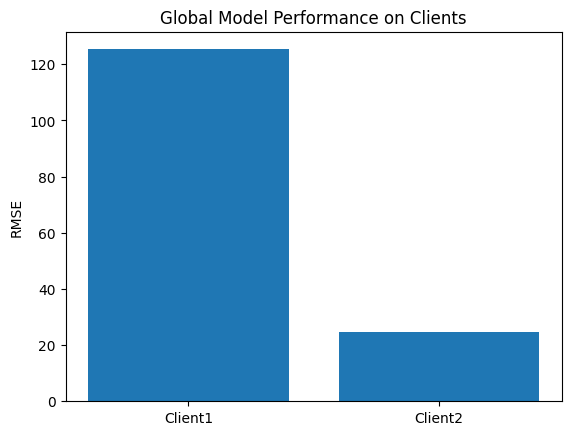

In [ ]:
import matplotlib.pyplot as plt

clients = ["Client1","Client2"]
rmse_values = [rmse_client1, rmse_client2]

plt.bar(clients, rmse_values)
plt.title("Global Model Performance on Clients")
plt.ylabel("RMSE")
plt.show()

In [ ]:
import pandas as pd

data = pd.read_csv("/content/ev_charging_patterns.csv")

In [ ]:
clients = {}

vehicle_models = data["Vehicle Model"].unique()

for model in vehicle_models:
    clients[model] = data[data["Vehicle Model"] == model]

print("Total Clients:", len(clients))

Total Clients: 5


In [ ]:
from sklearn.ensemble import RandomForestRegressor

client_params = {}

features = ["Charging Duration (hours)",
            "Charging Rate (kW)",
            "Temperature (°C)"]

for model_name, df in clients.items():

    df = df.dropna()

    X = df[features]
    y = df["Energy Consumed (kWh)"]

    model = RandomForestRegressor(n_estimators=50)
    model.fit(X, y)

    # extract insights (NOT raw data)
    avg_energy = y.mean()
    feature_importance = model.feature_importances_

    client_params[model_name] = {
        "avg_energy": avg_energy,
        "feature_importance": feature_importance
    }

    print(f"{model_name} trained and sent parameters")

BMW i3 trained and sent parameters
Hyundai Kona trained and sent parameters
Chevy Bolt trained and sent parameters
Nissan Leaf trained and sent parameters
Tesla Model 3 trained and sent parameters


In [ ]:
print("\nSending insights to server...\n")


Sending insights to server...



In [ ]:
import numpy as np

avg_energy_list = []
importance_list = []

for model_name, params in client_params.items():
    avg_energy_list.append(params["avg_energy"])
    importance_list.append(params["feature_importance"])

# global trends
global_avg_energy = np.mean(avg_energy_list)
global_importance = np.mean(importance_list, axis=0)

print("Global Average Energy:", global_avg_energy)
print("Global Feature Importance:", global_importance)

Global Average Energy: 42.878244168232314
Global Feature Importance: [0.34706401 0.32808193 0.32485406]


In [ ]:
df = data[data["Vehicle Model"] == model].copy()

In [ ]:
df["distance_km"] = df["Charging Duration (hours)"] * 40

In [ ]:
mileage_results = {}
for model_name, df in clients.items():

    df = df.copy()  # avoid warning

    # Step 1: Estimate distance (assume avg speed 40 km/h)
    df["distance_km"] = df["Charging Duration (hours)"] * 40

    # Step 2: Compute energy per km
    df["energy_per_km"] = df["Energy Consumed (kWh)"] / df["distance_km"]

    # Step 3: Remove invalid values (important)
    df = df.replace([float('inf'), -float('inf')], None).dropna()

    # Step 4: Average efficiency
    avg_efficiency = df["energy_per_km"].mean()

    # Step 5: Mileage calculation
    mileage = battery_capacity / avg_efficiency

    mileage_results[model_name] = mileage

    print(f"{model_name} → Estimated Mileage: {mileage:.2f} km")

BMW i3 → Estimated Mileage: 153.33 km
Hyundai Kona → Estimated Mileage: 161.93 km
Chevy Bolt → Estimated Mileage: 160.20 km
Nissan Leaf → Estimated Mileage: 146.54 km
Tesla Model 3 → Estimated Mileage: 139.61 km


In [ ]:
import numpy as np

all_efficiencies = []

for model_name, df in clients.items():

    df = df.copy()

    df["distance_km"] = df["Charging Duration (hours)"] * 40
    df["energy_per_km"] = df["Energy Consumed (kWh)"] / df["distance_km"]

    df = df.replace([float('inf'), -float('inf')], None).dropna()

    avg_efficiency = df["energy_per_km"].mean()

    all_efficiencies.append(avg_efficiency)

# global efficiency
global_efficiency = np.mean(all_efficiencies)

# global mileage
global_mileage = battery_capacity / global_efficiency

print("\n🌍 Global Federated Mileage:", global_mileage, "km")


🌍 Global Federated Mileage: 151.85301017074454 km
